Block 1 — Imports and Configuration

In [14]:
import os
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
import timm
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt

# -----------------------------
# Paths
# -----------------------------
DATA_ROOT = "../../data/Leaf/RiceLeafsDisease/"  # ImageFolder format
TRAIN_DIR = os.path.join(DATA_ROOT, "train_aug") 
VAL_DIR   = os.path.join(DATA_ROOT, "validation")  
TEST_DIR  = os.path.join(DATA_ROOT, "test")        

OUT_DIR = "./outputs" 
os.makedirs(OUT_DIR, exist_ok=True)

# -----------------------------
# Device and random seed
# -----------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42
torch.manual_seed(SEED)
random.seed(SEED)

# -----------------------------
# Dataset and training settings
# -----------------------------
NUM_CLASSES = 6  # explicitly set
BATCH_SIZE = 12
EPOCHS = 10
ACCUM_STEPS = 1
LR_LIST = [1e-4, 5e-5]
NUM_WORKERS = 2


In [15]:
def get_transforms(img_size, train=True):
    if train:
        return transforms.Compose([
            transforms.RandomResizedCrop(img_size, scale=(0.6, 1.0)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.RandomRotation(15),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.15, hue=0.02),
            transforms.ToTensor(),
            transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
        ])
    else:
        return transforms.Compose([
            transforms.Resize(int(img_size*1.14)),
            transforms.CenterCrop(img_size),
            transforms.ToTensor(),
            transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
        ])

class FieldDataset(Dataset):
    """Dataset for unlabeled field images (optional)."""
    def __init__(self, root_dir, transform=None):
        self.root_dir = Path(root_dir)
        self.paths = sorted([p for p in self.root_dir.iterdir() if p.suffix.lower() in [".jpg",".jpeg",".png"]])
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, str(path)


In [16]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split

def load_dataset(root_dir, img_size, batch_size, num_workers=2, val_split=0.2):
    train_transform = get_transforms(img_size, train=True)
    val_transform = get_transforms(img_size, train=False)

    full_dataset = ImageFolder(root_dir, transform=train_transform)
    class_names = full_dataset.classes
    num_classes = len(class_names)

    val_size = int(val_split * len(full_dataset))
    train_size = len(full_dataset) - val_size
    train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])
    val_dataset.dataset.transform = val_transform

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

    dataset_sizes = {"train": len(train_dataset), "val": len(val_dataset)}
    print(f"Loaded dataset from {root_dir} with {num_classes} classes")
    print(f"Train samples: {dataset_sizes['train']}, Val samples: {dataset_sizes['val']}")
    
    return train_loader, val_loader, num_classes, class_names, dataset_sizes
/

()

In [17]:
def build_model(name, num_classes=NUM_CLASSES, pretrained=True):
    """Return model with classifier adapted to num_classes."""
    if name.lower() == "resnet18":
        model = models.resnet18(pretrained=pretrained)
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)
    else:  # TIMM models
        model = timm.create_model(name, pretrained=pretrained, num_classes=num_classes)
    return model

def save_checkpoint(model, optimizer, epoch, path):
    state = {
        "state_dict": model.state_dict(),
        "optimizer": optimizer.state_dict(),
        "epoch": epoch
    }
    torch.save(state, path)
    print(f"Checkpoint saved to {path}")


In [18]:
def train_one_epoch(model, dataloader, criterion, optimizer, device, scaler=None, accumulation_steps=1):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    optimizer.zero_grad()

    for i, (images, labels) in enumerate(tqdm(dataloader)):
        images, labels = images.to(device), labels.to(device)
        with torch.cuda.amp.autocast(enabled=(scaler is not None)):
            outputs = model(images)
            loss = criterion(outputs, labels) / accumulation_steps

        if scaler:
            scaler.scale(loss).backward()
        else:
            loss.backward()

        if (i+1) % accumulation_steps == 0:
            if scaler:
                scaler.step(optimizer)
                scaler.update()
            else:
                optimizer.step()
            optimizer.zero_grad()

        running_loss += loss.item() * accumulation_steps
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / len(dataloader), correct / total

@torch.no_grad()
def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in tqdm(dataloader):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / len(dataloader), correct / total


In [19]:
def plot_history(history, model_name, lr):
    epochs = range(1, len(history["train_loss"])+1)
    plt.figure(figsize=(12,5))
    
    # Loss
    plt.subplot(1,2,1)
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{model_name} Loss (LR={lr})")
    plt.legend()
    
    # Accuracy
    plt.subplot(1,2,2)
    plt.plot(epochs, [a*100 for a in history["train_acc"]], label="Train Acc")
    plt.plot(epochs, [a*100 for a in history["val_acc"]], label="Val Acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title(f"{model_name} Accuracy (LR={lr})")
    plt.legend()
    
    plt.tight_layout()
    plt.show()


Loaded dataset from ../../data/Leaf/RiceLeafsDisease/train_aug with 6 classes
Train samples: 12000, Val samples: 3000

==== Fine-tuning vit_tiny_patch16_224 with LR=0.0001 ====


C:\Users\Acer\AppData\Local\Temp\ipykernel_29940\444346363.py:21: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()



Epoch 1/10


  0%|          | 0/1000 [00:00<?, ?it/s]C:\Users\Acer\AppData\Local\Temp\ipykernel_29940\896754853.py:8: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(scaler is not None)):
100%|██████████| 250/250 [00:16<00:00, 15.32it/s]


Train Loss: 0.2621, Train Acc: 90.68% | Val Loss: 0.1138, Val Acc: 95.40%
Checkpoint saved to ./outputs\vit_tiny_patch16_224_LR0.0001_best.pt

Epoch 2/10


...

Train Loss: 0.0354, Train Acc: 98.76% | Val Loss: 0.0808, Val Acc: 97.43%

Epoch 9/10


100%|██████████| 250/250 [00:25<00:00,  9.98it/s]


Train Loss: 0.0264, Train Acc: 99.26% | Val Loss: 0.0440, Val Acc: 98.57%
Checkpoint saved to ./outputs\vit_tiny_patch16_224_LR0.0001_best.pt

Epoch 10/10


100%|██████████| 250/250 [00:15<00:00, 16.01it/s]


Train Loss: 0.0315, Train Acc: 99.00% | Val Loss: 0.0561, Val Acc: 98.17%


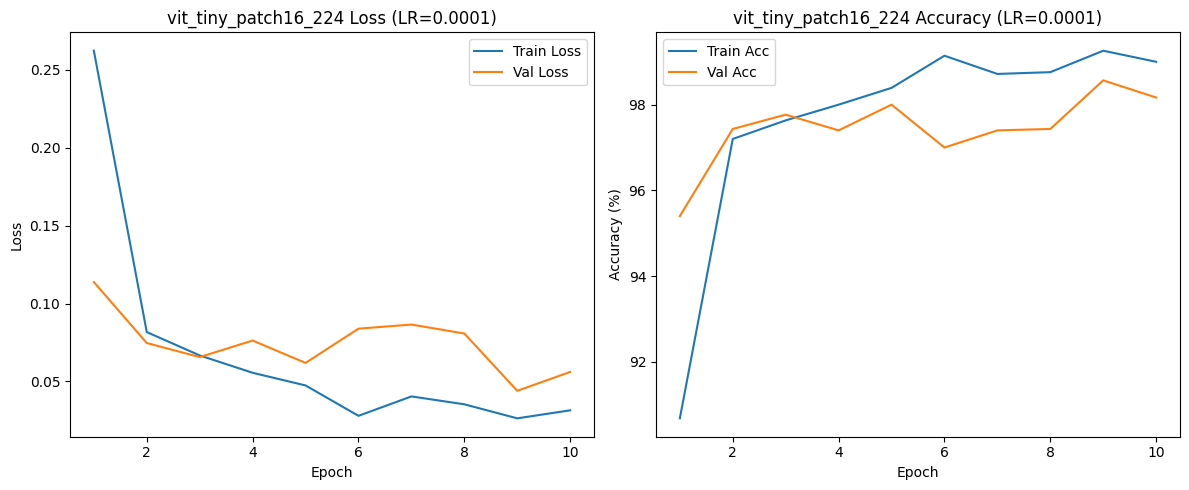


==== Fine-tuning vit_tiny_patch16_224 with LR=5e-05 ====

Epoch 1/10


100%|██████████| 250/250 [00:15<00:00, 16.21it/s]


Train Loss: 0.2151, Train Acc: 92.35% | Val Loss: 0.0863, Val Acc: 96.93%
Checkpoint saved to ./outputs\vit_tiny_patch16_224_LR5e-05_best.pt

Epoch 2/10


100%|██████████| 250/250 [00:15<00:00, 16.15it/s]


Train Loss: 0.0635, Train Acc: 97.80% | Val Loss: 0.0667, Val Acc: 97.67%
Checkpoint saved to ./outputs\vit_tiny_patch16_224_LR5e-05_best.pt

Epoch 3/10


...

Train Loss: 0.0147, Train Acc: 99.48% | Val Loss: 0.0362, Val Acc: 98.87%
Checkpoint saved to ./outputs\vit_tiny_patch16_224_LR5e-05_best.pt

Epoch 9/10


100%|██████████| 250/250 [00:15<00:00, 16.02it/s]


Train Loss: 0.0190, Train Acc: 99.48% | Val Loss: 0.0581, Val Acc: 98.50%

Epoch 10/10


100%|██████████| 250/250 [00:15<00:00, 16.07it/s]


Train Loss: 0.0156, Train Acc: 99.53% | Val Loss: 0.2195, Val Acc: 94.70%


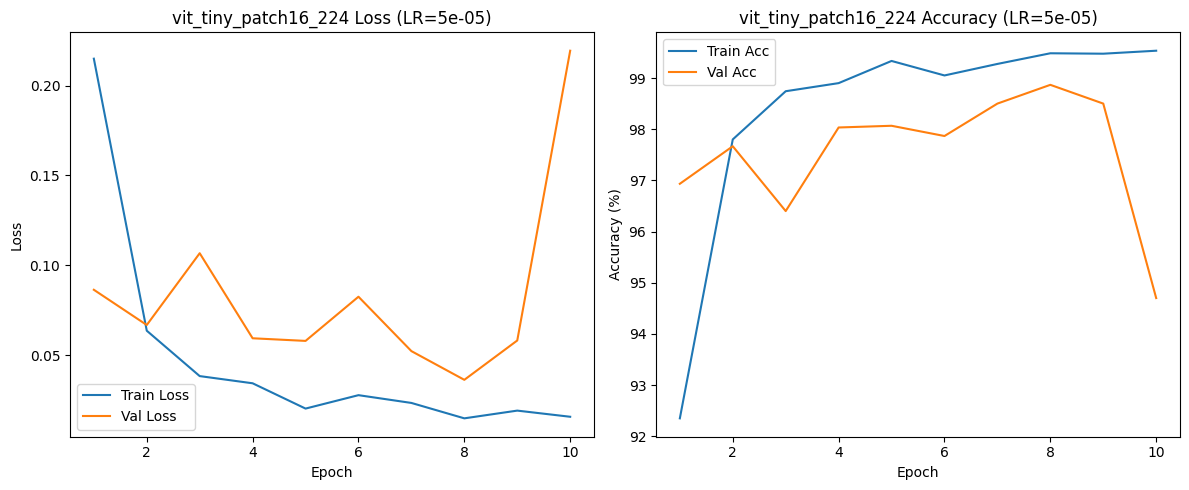

Loaded dataset from ../../data/Leaf/RiceLeafsDisease/train_aug with 6 classes
Train samples: 12000, Val samples: 3000

==== Fine-tuning efficientnet_b0 with LR=0.0001 ====

Epoch 1/10


100%|██████████| 250/250 [00:14<00:00, 17.21it/s]


Train Loss: 0.4787, Train Acc: 84.93% | Val Loss: 0.1188, Val Acc: 96.30%
Checkpoint saved to ./outputs\efficientnet_b0_LR0.0001_best.pt

Epoch 2/10


100%|██████████| 250/250 [00:14<00:00, 17.11it/s]


Train Loss: 0.0958, Train Acc: 96.42% | Val Loss: 0.0504, Val Acc: 98.67%
Checkpoint saved to ./outputs\efficientnet_b0_LR0.0001_best.pt

Epoch 3/10


...

Train Loss: 0.0203, Train Acc: 99.31% | Val Loss: 0.0268, Val Acc: 99.40%
Checkpoint saved to ./outputs\efficientnet_b0_LR0.0001_best.pt

Epoch 9/10


100%|██████████| 250/250 [00:16<00:00, 15.41it/s]


Train Loss: 0.0277, Train Acc: 99.19% | Val Loss: 0.0172, Val Acc: 99.50%
Checkpoint saved to ./outputs\efficientnet_b0_LR0.0001_best.pt

Epoch 10/10


100%|██████████| 250/250 [00:16<00:00, 15.41it/s]


Train Loss: 0.0157, Train Acc: 99.52% | Val Loss: 0.0424, Val Acc: 99.20%


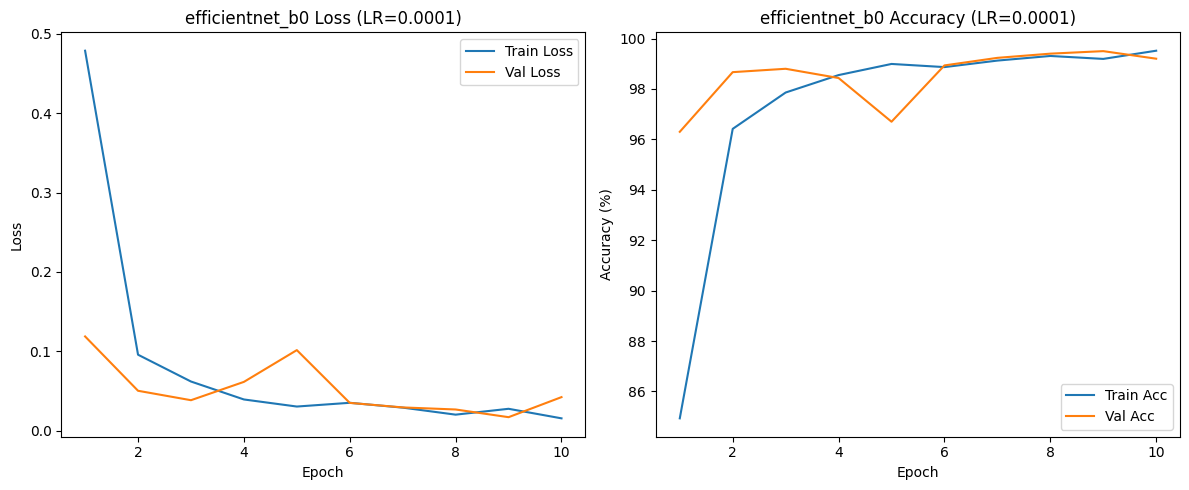


==== Fine-tuning efficientnet_b0 with LR=5e-05 ====

Epoch 1/10


100%|██████████| 250/250 [00:16<00:00, 15.44it/s]


Train Loss: 0.6365, Train Acc: 80.56% | Val Loss: 0.1417, Val Acc: 95.27%
Checkpoint saved to ./outputs\efficientnet_b0_LR5e-05_best.pt

Epoch 2/10


100%|██████████| 250/250 [00:16<00:00, 15.33it/s]


Train Loss: 0.1515, Train Acc: 94.58% | Val Loss: 0.0546, Val Acc: 97.97%
Checkpoint saved to ./outputs\efficientnet_b0_LR5e-05_best.pt

Epoch 3/10


...

Train Loss: 0.0176, Train Acc: 99.42% | Val Loss: 0.0228, Val Acc: 99.47%
Checkpoint saved to ./outputs\efficientnet_b0_LR5e-05_best.pt

Epoch 9/10


100%|██████████| 250/250 [00:15<00:00, 16.16it/s]


Train Loss: 0.0168, Train Acc: 99.41% | Val Loss: 0.0159, Val Acc: 99.47%

Epoch 10/10


100%|██████████| 250/250 [00:14<00:00, 16.87it/s]


Train Loss: 0.0153, Train Acc: 99.49% | Val Loss: 0.0291, Val Acc: 99.43%


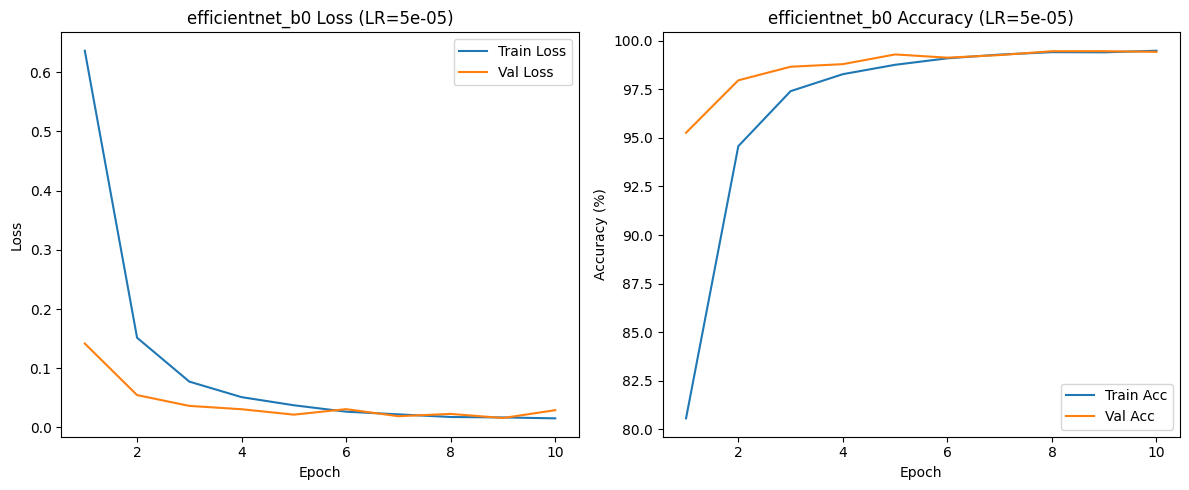

Loaded dataset from ../../data/Leaf/RiceLeafsDisease/train_aug with 6 classes
Train samples: 12000, Val samples: 3000

==== Fine-tuning mobilenetv3_small_100 with LR=0.0001 ====

Epoch 1/10


100%|██████████| 250/250 [00:12<00:00, 19.28it/s]


Train Loss: 0.5674, Train Acc: 82.99% | Val Loss: 0.1509, Val Acc: 94.00%
Checkpoint saved to ./outputs\mobilenetv3_small_100_LR0.0001_best.pt

Epoch 2/10


100%|██████████| 250/250 [00:14<00:00, 17.70it/s]


Train Loss: 0.1616, Train Acc: 94.08% | Val Loss: 0.1430, Val Acc: 95.27%
Checkpoint saved to ./outputs\mobilenetv3_small_100_LR0.0001_best.pt

Epoch 3/10


...

Train Loss: 0.0694, Train Acc: 97.74% | Val Loss: 0.2628, Val Acc: 90.63%

Epoch 9/10


100%|██████████| 250/250 [00:12<00:00, 19.76it/s]


Train Loss: 0.0701, Train Acc: 97.82% | Val Loss: 0.1147, Val Acc: 96.00%

Epoch 10/10


100%|██████████| 250/250 [00:12<00:00, 19.90it/s]


Train Loss: 0.0544, Train Acc: 98.28% | Val Loss: 0.0545, Val Acc: 98.13%
Checkpoint saved to ./outputs\mobilenetv3_small_100_LR0.0001_best.pt


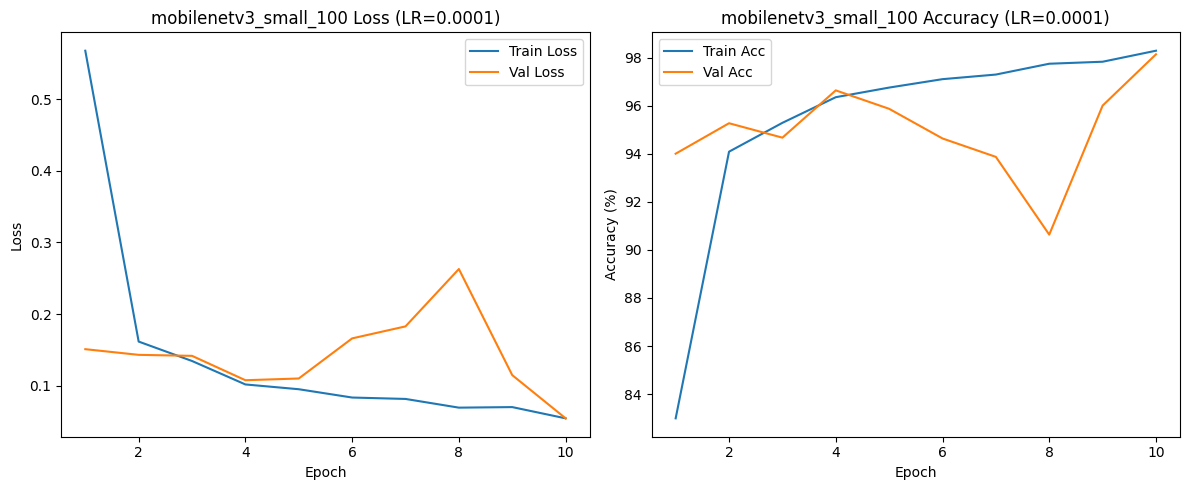


==== Fine-tuning mobilenetv3_small_100 with LR=5e-05 ====

Epoch 1/10


100%|██████████| 250/250 [00:12<00:00, 20.58it/s]


Train Loss: 0.5932, Train Acc: 81.98% | Val Loss: 0.1590, Val Acc: 94.33%
Checkpoint saved to ./outputs\mobilenetv3_small_100_LR5e-05_best.pt

Epoch 2/10


100%|██████████| 250/250 [00:12<00:00, 19.87it/s]


Train Loss: 0.1677, Train Acc: 94.00% | Val Loss: 0.0884, Val Acc: 96.93%
Checkpoint saved to ./outputs\mobilenetv3_small_100_LR5e-05_best.pt

Epoch 3/10


...

Train Loss: 0.0503, Train Acc: 98.21% | Val Loss: 0.0948, Val Acc: 96.73%

Epoch 9/10


100%|██████████| 250/250 [00:11<00:00, 21.12it/s]


Train Loss: 0.0467, Train Acc: 98.45% | Val Loss: 0.0509, Val Acc: 98.40%

Epoch 10/10


100%|██████████| 250/250 [00:14<00:00, 17.10it/s]


Train Loss: 0.0315, Train Acc: 98.89% | Val Loss: 0.0433, Val Acc: 98.57%


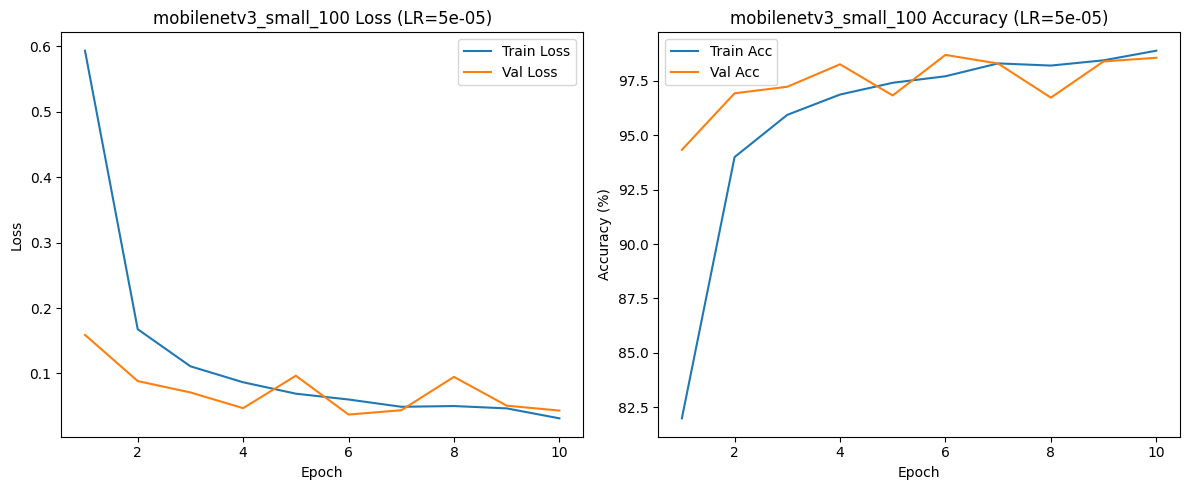

Loaded dataset from ../../data/Leaf/RiceLeafsDisease/train_aug with 6 classes
Train samples: 12000, Val samples: 3000

==== Fine-tuning resnet18 with LR=0.0001 ====


c:\Users\Acer\.conda\envs\nlp-env\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Acer\.conda\envs\nlp-env\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



Epoch 1/10


100%|██████████| 250/250 [00:14<00:00, 16.90it/s]


Train Loss: 0.2713, Train Acc: 90.57% | Val Loss: 0.0745, Val Acc: 97.23%
Checkpoint saved to ./outputs\resnet18_LR0.0001_best.pt

Epoch 2/10


...

Train Loss: 0.0280, Train Acc: 99.12% | Val Loss: 0.0347, Val Acc: 99.03%
Checkpoint saved to ./outputs\resnet18_LR0.0001_best.pt

Epoch 9/10


100%|██████████| 250/250 [00:14<00:00, 17.45it/s]


Train Loss: 0.0253, Train Acc: 99.27% | Val Loss: 0.0389, Val Acc: 98.53%

Epoch 10/10


100%|██████████| 250/250 [00:14<00:00, 17.57it/s]


Train Loss: 0.0310, Train Acc: 99.15% | Val Loss: 0.0312, Val Acc: 99.03%


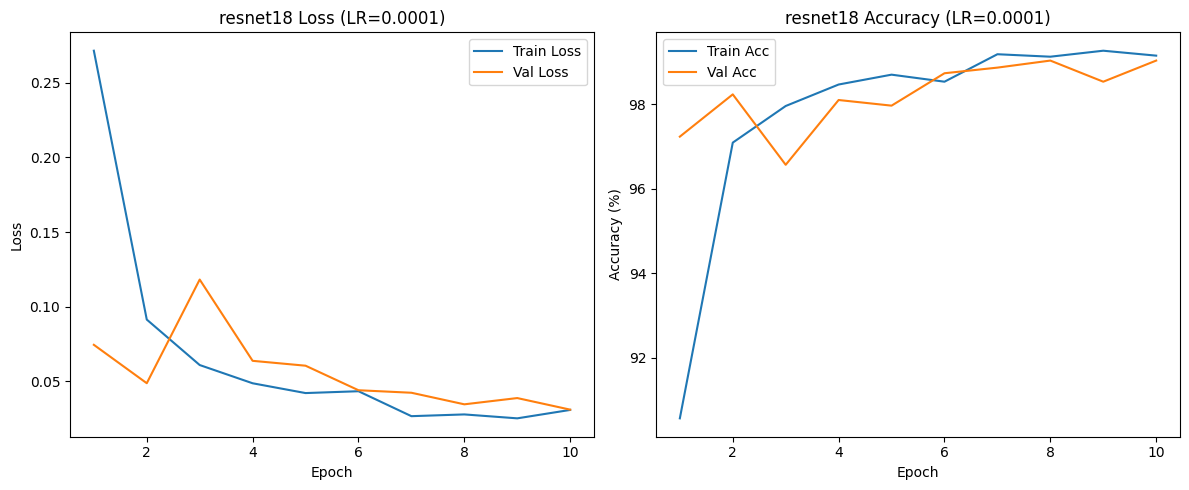


==== Fine-tuning resnet18 with LR=5e-05 ====

Epoch 1/10


100%|██████████| 250/250 [00:14<00:00, 17.56it/s]


Train Loss: 0.2805, Train Acc: 90.42% | Val Loss: 0.0764, Val Acc: 97.47%
Checkpoint saved to ./outputs\resnet18_LR5e-05_best.pt

Epoch 2/10


100%|██████████| 250/250 [00:16<00:00, 15.42it/s]


Train Loss: 0.0715, Train Acc: 97.83% | Val Loss: 0.0661, Val Acc: 97.93%
Checkpoint saved to ./outputs\resnet18_LR5e-05_best.pt

Epoch 3/10


...

Train Loss: 0.0194, Train Acc: 99.40% | Val Loss: 0.0613, Val Acc: 98.03%

Epoch 9/10


100%|██████████| 250/250 [00:15<00:00, 16.03it/s]


Train Loss: 0.0192, Train Acc: 99.41% | Val Loss: 0.0395, Val Acc: 98.80%

Epoch 10/10


100%|██████████| 250/250 [00:16<00:00, 15.39it/s]


Train Loss: 0.0144, Train Acc: 99.57% | Val Loss: 0.0462, Val Acc: 98.70%


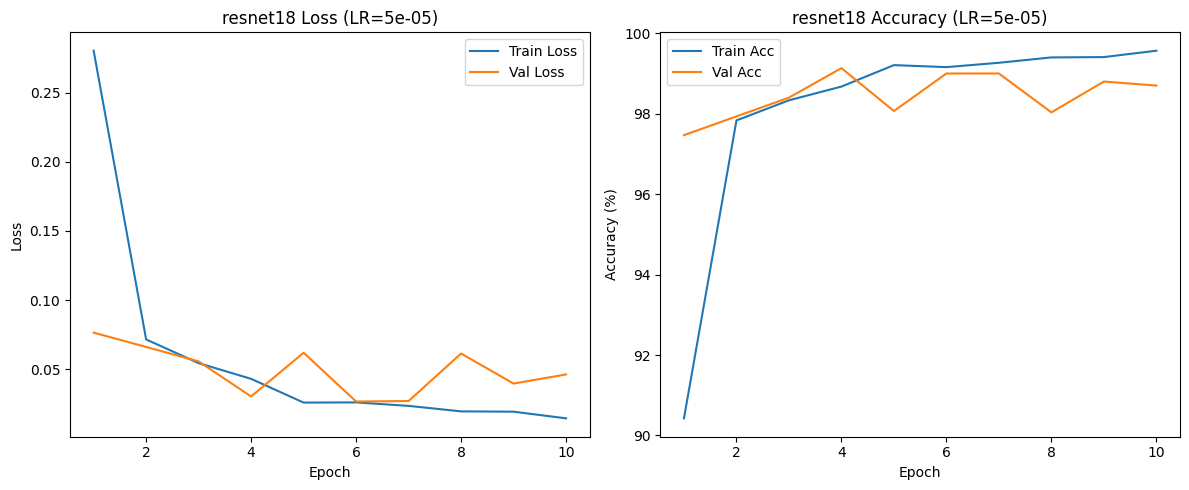

In [25]:
MODEL_SPECS = [
    {"name": "vit_tiny_patch16_224", "img_size": 224, "pretrained": True},
    {"name": "efficientnet_b0", "img_size": 224, "pretrained": True},
    {"name": "mobilenetv3_small_100", "img_size": 224, "pretrained": True},
    {"name": "resnet18", "img_size": 224, "pretrained": True},
]

for model_spec in MODEL_SPECS:
    img_size = model_spec["img_size"]
    train_loader, val_loader, num_classes, class_names, _ = load_dataset(
        TRAIN_DIR, img_size, BATCH_SIZE, NUM_WORKERS
    )
    
    for lr in LR_LIST:
        print(f"\n==== Fine-tuning {model_spec['name']} with LR={lr} ====")
        
        # Build model
        model = build_model(model_spec["name"], num_classes=num_classes, pretrained=model_spec["pretrained"]).to(DEVICE)
        optimizer = optim.Adam(model.parameters(), lr=lr)
        criterion = nn.CrossEntropyLoss()
        scaler = torch.cuda.amp.GradScaler()
        
        history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
        best_acc = 0.0
        
        for epoch in range(EPOCHS):
            print(f"\nEpoch {epoch+1}/{EPOCHS}")
            
            # Train one epoch
            train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE, scaler, ACCUM_STEPS)
            
            # Evaluate on validation set
            val_loss, val_acc = evaluate(model, val_loader, criterion, DEVICE)
            
            # Print both train and val metrics
            print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc*100:.2f}% | "
                  f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc*100:.2f}%")
            
            # Save history for plotting
            history["train_loss"].append(train_loss)
            history["train_acc"].append(train_acc)
            history["val_loss"].append(val_loss)
            history["val_acc"].append(val_acc)
            
            # Save best checkpoint
            if val_acc > best_acc:
                best_acc = val_acc
                ckpt_path = os.path.join(OUT_DIR, f"{model_spec['name']}_LR{lr}_best.pt")
                save_checkpoint(model, optimizer, epoch, ckpt_path)
        
        # Plot metrics
        plot_history(history, model_spec["name"], lr)
        
        # Clear GPU memory
        del model, optimizer, scaler
        torch.cuda.empty_cache()
